## 1. Load the VIS cutout

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from astropy.convolution import Gaussian2DKernel, convolve
from astropy.io import fits
from astropy.visualization import AsinhStretch, ImageNormalize, PercentileInterval
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from matplotlib.patches import Circle

project_root = Path(r"D:\AST\07_Euclid_Q1_Case_Study")
vis_cutout_path = project_root / "data" / "cutouts" / "NGC6505_VIS_r0p1arcmin.fits"
output_directory = project_root / "outputs" / "figures"

target_ra, target_dec = 267.78130284070573, 65.53074243100221
published_einstein_radius_arcsec = 2.5

if not vis_cutout_path.exists():
    raise FileNotFoundError(vis_cutout_path)

with fits.open(vis_cutout_path, memmap=True) as hdul:
    vis_image = hdul[0].data.astype(float, copy=True)
    vis_header = hdul[0].header.copy()

vis_wcs = WCS(vis_header)
pixel_scale_arcsec = float(proj_plane_pixel_scales(vis_wcs).mean() * 3600)
target_x, target_y = vis_wcs.world_to_pixel_values(target_ra, target_dec)
image_center_x, image_center_y = (vis_image.shape[1] - 1) / 2, (vis_image.shape[0] - 1) / 2
center_offset_arcsec = np.hypot(target_x - image_center_x, target_y - image_center_y) * pixel_scale_arcsec

print("Image shape:", vis_image.shape)
print("Pixel scale:", pixel_scale_arcsec, "arcsec/pixel")
print("Target pixel:", target_x, target_y)
print("Center offset:", center_offset_arcsec, "arcsec")
print("Published Einstein radius:", published_einstein_radius_arcsec, "arcsec")

Image shape: (122, 122)
Pixel scale: 0.100000000000008 arcsec/pixel
Target pixel: 60.65884358072253 59.92754139123372
Center offset: 0.059408765505389885 arcsec
Published Einstein radius: 2.5 arcsec


## 2. Estimate the Einstein-ring radius

In [2]:
smoothing_sigma_pixels = 8.0
smooth_galaxy_model = convolve(vis_image, Gaussian2DKernel(smoothing_sigma_pixels), boundary="extend", normalize_kernel=True)
vis_residual = vis_image - smooth_galaxy_model

y_grid, x_grid = np.indices(vis_image.shape)
radius_grid_arcsec = np.hypot(x_grid - target_x, y_grid - target_y) * pixel_scale_arcsec
radial_bin_edges = np.arange(0, 5.0 + pixel_scale_arcsec, pixel_scale_arcsec)
radial_bin_centers = (radial_bin_edges[:-1] + radial_bin_edges[1:]) / 2

radial_profile = np.array([
    np.nanpercentile(vis_residual[(radius_grid_arcsec >= lower) & (radius_grid_arcsec < upper)], 90)
    for lower, upper in zip(radial_bin_edges[:-1], radial_bin_edges[1:])
])

search_region = (radial_bin_centers >= 1.5) & (radial_bin_centers <= 3.5)
estimated_radius_arcsec = radial_bin_centers[search_region][np.nanargmax(radial_profile[search_region])]
radius_difference_arcsec = estimated_radius_arcsec - published_einstein_radius_arcsec

print("Estimated Einstein radius:", estimated_radius_arcsec, "arcsec")
print("Published Einstein radius:", published_einstein_radius_arcsec, "arcsec")
print("Difference:", radius_difference_arcsec, "arcsec")

Estimated Einstein radius: 2.850000000000228 arcsec
Published Einstein radius: 2.5 arcsec
Difference: 0.3500000000002279 arcsec


## 3. Refine the lens centre

In [3]:
core_mask = radius_grid_arcsec <= 0.8
background_mask = (radius_grid_arcsec > 0.8) & (radius_grid_arcsec <= 1.2)
core_background = np.nanmedian(vis_image[background_mask])
core_weights = np.where(core_mask, np.clip(vis_image - core_background, 0, None), 0)

refined_x = np.nansum(x_grid * core_weights) / np.nansum(core_weights)
refined_y = np.nansum(y_grid * core_weights) / np.nansum(core_weights)
centre_shift_arcsec = np.hypot(refined_x - target_x, refined_y - target_y) * pixel_scale_arcsec

refined_radius_grid_arcsec = np.hypot(x_grid - refined_x, y_grid - refined_y) * pixel_scale_arcsec
refined_radial_profile = np.array([
    np.nanpercentile(vis_residual[(refined_radius_grid_arcsec >= lower) & (refined_radius_grid_arcsec < upper)], 90)
    for lower, upper in zip(radial_bin_edges[:-1], radial_bin_edges[1:])
])

refined_estimated_radius_arcsec = radial_bin_centers[search_region][np.nanargmax(refined_radial_profile[search_region])]
refined_difference_arcsec = refined_estimated_radius_arcsec - published_einstein_radius_arcsec

print("Refined centre:", refined_x, refined_y)
print("Centre shift:", centre_shift_arcsec, "arcsec")
print("Refined Einstein radius:", refined_estimated_radius_arcsec, "arcsec")
print("Difference from published value:", refined_difference_arcsec, "arcsec")

Refined centre: 62.788033356854555 60.31478435762543
Centre shift: 0.21641178844521697 arcsec
Refined Einstein radius: 2.6500000000002117 arcsec
Difference from published value: 0.15000000000021174 arcsec


## 4. Compare and save the final measurement

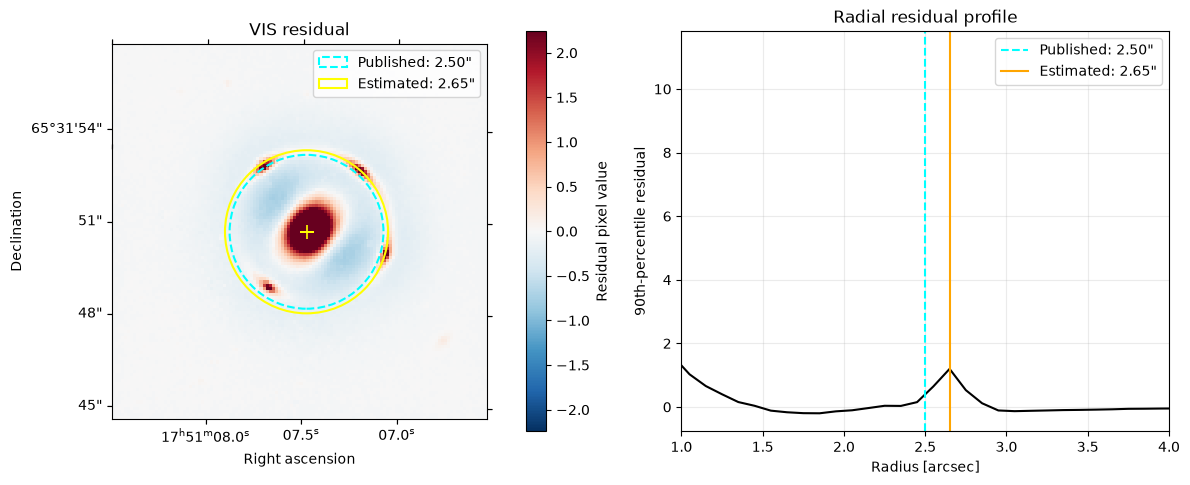

Saved figure: D:\AST\07_Euclid_Q1_Case_Study\outputs\figures\ngc6505_ring_radius_measurement.png
Saved result: D:\AST\07_Euclid_Q1_Case_Study\outputs\tables\ngc6505_ring_radius_measurement.csv


In [4]:
display_mask = (refined_radius_grid_arcsec > 0.5) & (refined_radius_grid_arcsec < 5.0)
residual_limit = np.nanpercentile(np.abs(vis_residual[display_mask]), 99)
published_radius_pixels = published_einstein_radius_arcsec / pixel_scale_arcsec
estimated_radius_pixels = refined_estimated_radius_arcsec / pixel_scale_arcsec

figure_output_path = output_directory / "ngc6505_ring_radius_measurement.png"
result_output_path = project_root / "outputs" / "tables" / "ngc6505_ring_radius_measurement.csv"

fig = plt.figure(figsize=(12, 5))
ax_image = fig.add_subplot(1, 2, 1, projection=vis_wcs)
ax_profile = fig.add_subplot(1, 2, 2)

residual_artist = ax_image.imshow(vis_residual, origin="lower", cmap="RdBu_r", vmin=-residual_limit, vmax=residual_limit)
ax_image.add_patch(Circle((refined_x, refined_y), published_radius_pixels, fill=False, color="cyan", linestyle="--", linewidth=1.5, label='Published: 2.50"'))
ax_image.add_patch(Circle((refined_x, refined_y), estimated_radius_pixels, fill=False, color="yellow", linewidth=1.5, label=f'Estimated: {refined_estimated_radius_arcsec:.2f}"'))
ax_image.plot(refined_x, refined_y, marker="+", color="yellow", markersize=10, markeredgewidth=1.2)
ax_image.set_title("VIS residual")
ax_image.coords[0].set_axislabel("Right ascension")
ax_image.coords[1].set_axislabel("Declination")
ax_image.legend(loc="upper right")
fig.colorbar(residual_artist, ax=ax_image, pad=0.08, label="Residual pixel value")

ax_profile.plot(radial_bin_centers, refined_radial_profile, color="black")
ax_profile.axvline(published_einstein_radius_arcsec, color="cyan", linestyle="--", label='Published: 2.50"')
ax_profile.axvline(refined_estimated_radius_arcsec, color="orange", label=f'Estimated: {refined_estimated_radius_arcsec:.2f}"')
ax_profile.set(xlim=(1, 4), xlabel="Radius [arcsec]", ylabel="90th-percentile residual", title="Radial residual profile")
ax_profile.grid(alpha=0.25)
ax_profile.legend()

fig.tight_layout()
fig.savefig(figure_output_path, dpi=300, bbox_inches="tight")
plt.show()

result_values = [[refined_x, refined_y, centre_shift_arcsec, refined_estimated_radius_arcsec, published_einstein_radius_arcsec, refined_difference_arcsec]]
result_header = "refined_x_pixel,refined_y_pixel,centre_shift_arcsec,estimated_radius_arcsec,published_radius_arcsec,difference_arcsec"
np.savetxt(result_output_path, result_values, delimiter=",", header=result_header, comments="")

print("Saved figure:", figure_output_path)
print("Saved result:", result_output_path)